In [ ]:
from IPython.display import HTML

custom_css = """
<style>
    /* Overall and background fonts */
    body, .jp-Notebook {
        font-family: 'Segoe UI', -apple-system, BlinkMacSystemFont, Roboto, sans-serif !important;
        color: #1e293b !important;
        line-height: 1.6 !important;
    }
    
    /* Main titles (H1, H2, H3) */
    h1 {
        color: #0f172a !important;
        border-bottom: 3px solid #2563eb !important;
        padding-bottom: 8px !important;
        margin-top: 24px !important;
        font-weight: 700 !important;
    }
    h2 {
        color: #1e40af !important;
        border-bottom: 1px solid #cbd5e1 !important;
        padding-bottom: 5px !important;
        margin-top: 20px !important;
        font-weight: 600 !important;
    }
    h3 {
        color: #1d4ed8 !important;
        margin-top: 16px !important;
        font-weight: 600 !important;
    }
    
    /* Stylised Markdown tables */
    table {
        border-collapse: collapse !important;
        width: 100% !important;
        margin: 20px 0 !important;
        font-size: 0.95em !important;
        box-shadow: 0 1px 3px rgba(0,0,0,0.1) !important;
        border-radius: 6px !important;
        overflow: hidden !important;
    }
    th {
        background-color: #1e40af !important;
        color: white !important;
        text-align: left !important;
        padding: 12px 15px !important;
        font-weight: 600 !important;
    }
    td {
        padding: 10px 15px !important;
        border-bottom: 1px solid #e2e8f0 !important;
    }
    tr:nth-child(even) {
        background-color: #f8fafc !important;
    }
    tr:hover {
        background-color: #f1f5f9 !important;
    }
    
    /* Blockquotes */
    blockquote {
        background-color: #eff6ff !important;
        border-left: 5px solid #2563eb !important;
        margin: 15px 0 !important;
        padding: 12px 20px !important;
        color: #1e3a8a !important;
        border-radius: 0 6px 6px 0 !important;
    }
</style>
"""

HTML(custom_css)

# FinTrust Digital Bank — Risk Intelligence & Predictive Modeling
**Track:** Data Science  
**Phase:** Week 1 — Problem Definition, Target Assessment & Data Profiling  
**Author:** Dorian NJAMI - Certified Data Scientist  

---

## 1. Executive Context & Business Understanding
FinTrust Digital Bank is scaling its digital financial services across transactions and customer operations. To maintain platform integrity and mitigate operational risk, the bank requires an automated predictive capability to identify high-risk financial transactions in real time.

### 1.1 Predictive Problem Statement (Part A)
* **Objective:** Predict whether an incoming transaction requires formal risk review (`Risk_Review_Flag` = Yes);
* **Business Value:** Enables proactive risk management, reduces operational workloads for compliance officers, and prevents fraudulent activity before settlement;
* **Primary Stakeholders:** Fraud Operations, Risk & Compliance Team, Customer Support;
* **Success Criteria:** High Precision-Recall AUC (PR-AUC), high F1-Score on the minority risk class, and real-time prediction latency (< 100ms).

### 1.2 Target Variable Assessment (Part B)
* **Target Field:** `Risk_Review_Flag`
* **Type & Values:** Binary Categorical (`Yes` / `No`)
* **Nature:** Synthetic indicator created for risk assessment exercises
* **Expected Distribution:** Heavily imbalanced (the vast majority of daily banking transactions are legitimate)
* **Target Limitations:** As a synthetic label, it serves as a proxy for risk review rather than confirmed historical fraud ground truth.

---

In [6]:
# Libraries Import & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set Display Options
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Load Datasets
customer_df = pd.read_csv('../data/FinTrust_Customer_Data.csv')
transaction_df = pd.read_csv('../data/FinTrust_Transaction_Data.csv')

print(f"Customer Dataset Shape: {customer_df.shape}")
print(f"Transaction Dataset Shape: {transaction_df.shape}")

# Target Variable Class Imbalance Assessment
target_counts = transaction_df['Risk_Review_Flag'].value_counts()
target_props = transaction_df['Risk_Review_Flag'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_props.round(2)
})

print("=== Target Distribution (Risk_Review_Flag) ===")
display(target_summary)

Customer Dataset Shape: (1500, 12)
Transaction Dataset Shape: (12000, 11)
=== Target Distribution (Risk_Review_Flag) ===


,Count,Percentage (%)
Risk_Review_Flag,,
No,9648,80.4
Yes,2352,19.6


### 1.3. Candidate Features Assessment (Part C)
To prepare the dataset for predictive modeling, we merge the `Customer` and `Transaction` tables using an `inner join` on `Customer_ID`. This provides a consolidated feature space combining demographic attributes with transactional behavior.

Below, we engineer and inspect candidate features across both tables before performing feature selection and dimensionality reduction (e.g., PCA or correlation filtering).

Merged Dataset Shape: (12000, 22)
Columns in Merged Dataset: ['Transaction_ID', 'Customer_ID', 'Transaction_DateTime', 'Transaction_Type', 'Amount_NGN', 'Channel', 'Device_Type', 'Location', 'International_Transaction', 'Transaction_Status', 'Risk_Review_Flag', 'Customer_Name', 'Age', 'Gender', 'City', 'Customer_Segment', 'Account_Type', 'Tenure_Months', 'Digital_Engagement_Score', 'Monthly_Income_Band', 'Preferred_Channel', 'Account_Status']


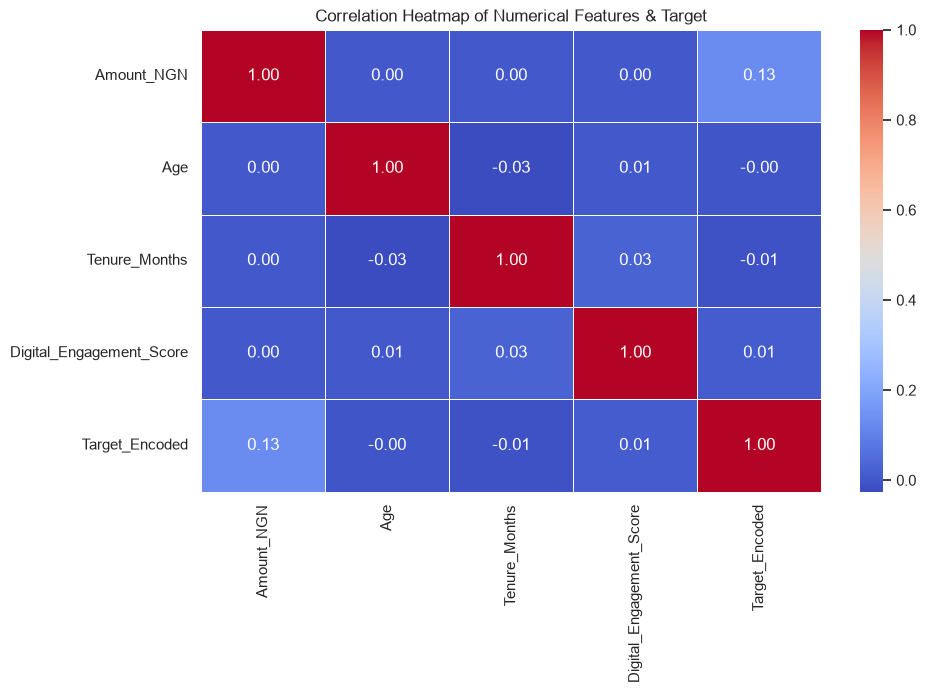


Missing values in merged dataset:
Device_Type    96
Location       96
dtype: int64


In [7]:
# Inner Join of Customer and Transaction Datasets
merged_df = pd.merge(transaction_df, customer_df, on='Customer_ID', how='inner')

print(f"Merged Dataset Shape: {merged_df.shape}")
print("Columns in Merged Dataset:", merged_df.columns.tolist())

# Numeric Encoding for Correlation Inspection
numeric_df = merged_df.select_dtypes(include=[np.number]).copy()

# Add encoded Target for correlation checking
numeric_df['Target_Encoded'] = (merged_df['Risk_Review_Flag'] == 'Yes').astype(int)

# Compute Correlation Matrix
plt.figure(figsize=(10, 6))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features & Target")
plt.show()

# Display missingness in merged dataframe
print("\nMissing values in merged dataset:")
print(merged_df.isnull().sum()[merged_df.isnull().sum() > 0])

#### 1.3.1 Correlation Heatmap Interpretation & Feature Selection Methodology

##### Heatmap Analysis & Limitations
The Pearson correlation matrix above evaluates only **linear relationships between continuous numerical features**:
* **Weak Linear Signal:** Features such as `Age` ($r = -0.00$), `Tenure_Months` ($r = -0.01$), and `Digital_Engagement_Score` ($r = 0.01$) show near-zero linear correlation with `Target_Encoded` (`Risk_Review_Flag`)
* **Primary Numerical Signal:** `Amount_NGN` shows a positive linear correlation ($r = 0.13$) with the target, indicating that higher transaction values moderately increase the likelihood of a risk review trigger
* **Methodological Limitation:** Because FinTrust's datasets heavily rely on categorical attributes (`Transaction_Type`, `Channel`, `Device_Type`, `Location`, `International_Transaction`, `Monthly_Income_Band`), linear Pearson correlation is insufficient to determine feature relevance.

##### Candidate Selection Framework
Instead of relying solely on linear correlation or intuition, feature selection for mixed tabular data relies on a three-tier framework:
1. **Domain Risk Relevance:** Financial risk patterns inherent to transaction channels and user behaviors.
2. **Categorical Association Metrics:** Statistical tests ($\chi^2$ test of independence, Cramér's V, and Mutual Information Score) designed to detect non-linear dependencies between categorical predictors and binary targets.
3. **Behavioral Anomaly Rationale:** Cross-referencing customer baseline profiles with individual transaction occurrences.

---

#### 1.3.2 Candidate Features Table (Part C Deliverable)

Below is the structured assessment of **12 candidate features** selected across the merged Customer-Transaction dataset:

| Feature Name | Source Table | Data Type | Why It May Matter (Risk Rationale) |
| :--- | :--- | :--- | :--- |
| `Amount_NGN` | Transaction | Decimal | Primary indicator of financial exposure; high-value transfers trigger automated compliance rules |
| `Transaction_Type` | Transaction | Categorical | Specific operations (e.g., Wire Transfers, International Payments) carry higher inherent fraud velocity than domestic merchant payments | 
| `Channel` | Transaction | Categorical | Risk exposure varies across channels (e.g., Web API vs. Mobile App vs. POS) | 
| `Device_Type` | Transaction | Categorical | Unrecognized, obsolete, or rapidly switching devices often indicate account takeover | 
| `Location` | Transaction | Categorical | Geographic anomalies (e.g., transactions originating from unusual cities or high-risk jurisdictions) |
| `International_Transaction` | Transaction | Binary Categorical | Cross-border payments carry significantly higher regulatory and fraud risk profiles |
| `Transaction_Status` | Transaction | Categorical | Repeated failed or pending transactions prior to execution may signal brute-force or unauthorized attempts |
| `Monthly_Income_Band` | Customer | Categorical | Serves as a baseline to evaluate whether `Amount_NGN` is proportional to the customer's expected financial capacity |
| `Digital_Engagement_Score` | Customer | Decimal | Sudden high-value digital transactions from customers with historically low engagement scores signal anomalous account usage |
| `Tenure_Months` | Customer | Integer | Newly created accounts ("low tenure") statistically present higher early-life fraud and chargeback risk |
| `City` | Customer | Categorical | Customer registered residence; useful for engineering a `Location_Mismatch` feature against transaction `Location`. | 
| `Account_Type` | Customer | Categorical | Business vs. Savings accounts have distinct transaction velocity and volume expectations |

## 2. Prepare
### 2.1 Risk Factors Hypotheses (Part D)

To guide feature engineering and exploratory data analysis, we establish the following preliminary hypotheses regarding factors associated with `Risk_Review_Flag`:

> **Methodological Note:** In accordance with project guidelines, these statements represent provisional research hypotheses to be tested statistically, rather than definitive empirical conclusions.

---

### Hypothesis 1: Transaction Value relative to Customer Income
* **Research Hypothesis:** Transactions where the monetary amount (`Amount_NGN`) is disproportionately high relative to the customer's `Monthly_Income_Band` are more likely to be flagged for risk review.
* **Null Hypothesis ($H_0$):** There is no significant difference in the amount-to-income ratio between transactions flagged for risk review (`Risk_Review_Flag = Yes`) and unflagged transactions (`Risk_Review_Flag = No`).
* **Alternative Hypothesis ($H_1$):** Transactions flagged for risk review exhibit a significantly higher amount-to-income ratio than unflagged transactions.
* **Planned Statistical Test:** Non-parametric Mann-Whitney U Test / Two-sample t-test.

---

### Hypothesis 2: Device Type Verification and Anomaly
* **Research Hypothesis:** Transactions originating from missing or unverified device types (`Device_Type`) carry a higher probability of being flagged for risk review compared to recognized devices.
* **Null Hypothesis ($H_0$):** The presence of a missing/unverified `Device_Type` is statistically independent of the `Risk_Review_Flag` status.
* **Alternative Hypothesis ($H_1$):** Transactions with missing/unverified `Device_Type` categories are significantly associated with a higher proportion of risk review flags.
* **Planned Statistical Test:** Chi-Square ($\chi^2$) Test of Independence.

---

### Hypothesis 3: Customer Tenure and Account Maturity
* **Research Hypothesis:** Newer accounts (low `Tenure_Months`) executing high-frequency transfers present a higher likelihood of risk review flags than established accounts.
* **Null Hypothesis ($H_0$):** Customer tenure length has no relationship with the transaction risk review rate.
* **Alternative Hypothesis ($H_1$):** Customers with lower account tenure have a statistically higher risk review flag rate during transfer operations.
* **Planned Statistical Test:** Logistic Regression odds ratio evaluation / Point-biserial correlation test. 

---

### Hypothesis 4: Cross-Border & Channel Exposure
* **Research Hypothesis:** Cross-border transactions (`International_Transaction = Yes`) performed via web channels exhibit a higher risk review rate than domestic mobile app transactions.
* **Null Hypothesis ($H_0$):** International transaction status and channel selection do not affect the distribution of the `Risk_Review_Flag`.
* **Alternative Hypothesis ($H_1$):** International transactions conducted via web channels have a significantly higher probability of being flagged for risk review.
* **Planned Statistical Test:** Two-way ANOVA / Chi-Square ($\chi^2$) Test on interaction terms.

---

### 2.2. Initial Modelling Plan (Part E)

The proposed end-to-end Machine Learning plan for the FinTrust Risk Review problem covers 9 steps:

#### 2.2.1 Data Preparation
* Merge `Customer` and `Transaction` datasets on `Customer_ID`
* Handle missing values in `Device_Type` and `Location` using explicit `"Unknown"` category encoding or mode imputation
* Encode categorical variables using One-Hot Encoding for nominal variables and Ordinal Encoding for `Monthly_Income_Band`
* Apply `RobustScaler` or `StandardScaler` to numerical attributes (`Amount_NGN`, `Tenure_Months`, `Digital_Engagement_Score`) to handle skewness.

#### 2.2.2 Exploratory Analysis (EDA)
* Analyze the target distribution of `Risk_Review_Flag` to quantify class imbalance
* **Testing Hypothesis 1 ($H_1$):** Perform a Mann-Whitney U test comparing `Amount_NGN` distributions across `Risk_Review_Flag` classes
* **Testing Hypothesis 2 ($H_2$):** Execute a Chi-Square ($\chi^2$) Test of Independence between missing/unverified `Device_Type` and `Risk_Review_Flag`
* **Testing Hypothesis 3 ($H_3$):** Measure correlation and odds ratios between `Tenure_Months` and transfer risk flags
* **Testing Hypothesis 4 ($H_4$):** Analyze interaction effects between `International_Transaction = Yes`, `Channel`, and the risk target

#### 2.2.3 Feature Engineering
* **Relative Transaction Ratio:** Ratio of `Amount_NGN` to the estimated midpoint of `Monthly_Income_Band`
* **Device Anomaly Flag:** Binary indicator representing whether `Device_Type` is missing or unverified
* **Location Mismatch Flag:** Comparison between customer registered `City` and transaction `Location`
* **Dimensionality Reduction:** Dimensionality reduction via Principal Component Analysis (PCA) on continuous behavioral features to extract uncorrelated variance components. If necessary

#### 2.2.4 Baseline Model
* Implement a simple **Logistic Regression** and a **DummyClassifier** (predicting majority class/stratified) to establish lower-bound performance benchmarks.

#### 2.2.5 Candidate Algorithms
* **Supervised Classifiers:** Random Forest Classifier, XGBoost / LightGBM, and a PyTorch Multi-Layer Perceptron (MLP) for non-linear risk scoring
* **Unsupervised Anomaly Detection:** K-Means Clustering and Isolation Forest / Autoencoders trained exclusively on normal transactions (`Risk_Review_Flag = No`) to generate anomaly risk scores
* **Hybrid Ensemble:** Combining supervised probability scores with unsupervised anomaly distance metrics to produce a unified Risk Score

#### 2.2.6 Evaluation Metrics
* Standard accuracy is strictly excluded due to severe class imbalance
* Primary evaluation metrics: **Precision-Recall Curve (PR-AUC)**, **F1-Score** (focused on the positive `Risk_Review_Flag = Yes` class), and **Recall** (to minimize false negatives in fraud screening).

#### 2.2.7 Validation Strategy
* Utilize **Stratified 5-Fold Cross-Validation** to maintain class ratio integrity across folds
* If temporal patterns exist in `Transaction_DateTime`, evaluate a time-based train/test split to prevent data leakage

#### 2.2.8 Error Analysis
* Construct Confusion Matrices to analyze False Positives (legitimate transactions blocked) vs False Negatives (risky transactions missed)
* Extract Feature Importances (Gini / SHAP values) to verify whether features derived from hypotheses $H_1$ through $H_4$ serve as primary decision drivers for the trained models

#### 2.2.9 Model Limitations
* `Risk_Review_Flag` is a synthetic educational label and may not perfectly reflect real-world bank fraud mechanisms
* Static batch modeling lacks immediate adaptation to novel fraud tactics without periodic retrain pipelines.